# Análisis del proyecto

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import Funciones as f
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

Hemos cargado los datos a SQL obteniendo las siguientes tablas conectadas:

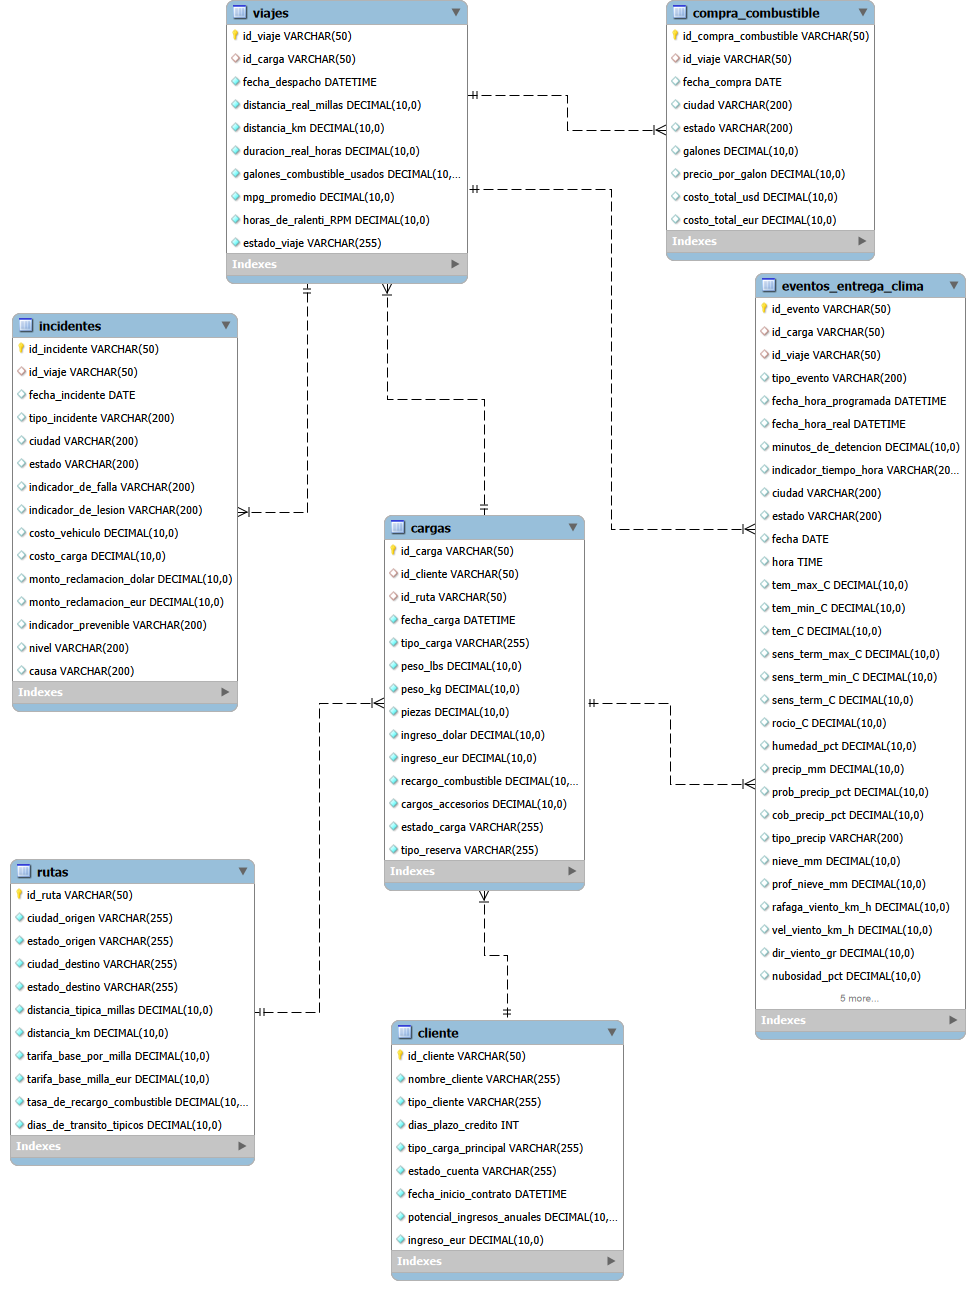

In [2]:
display(Image(filename='diagrama.png', width=600, height=400))

Detalle de las variables de estudio en cada tabla y como se relacionan:

1. eventos_entrega_clima = 'id_evento'(primary key), 'id_carga'(foreign key), 'id_viaje'(foreign key), 'tipo_evento',
       'fecha_hora_programada', 'fecha_hora_real', 'minutos_de_detencion',
       'indicador_tiempo_hora', 'ciudad', 'estado', 'fecha', 'hora',
       'tem_max_C', 'tem_min_C', 'tem_C', 'sens_term_max_C', 'sens_term_min_C',
       'sens_term_C', 'rocio_C', 'humedad_pct', 'precip_mm', 'prob_precip_pct',
       'cob_precip_pct', 'tipo_precip', 'nieve_mm', 'prof_nieve_mm',
       'rafaga_viento_km/h', 'vel_viento_km/h', 'dir_viento_gr', 'nubosidad_pct',
       'visibilidad_km', 'riesgo_severo', 'condiciones', 'descripcion',
       'icono'

2. rutas= 'id_ruta'(primary key), 'ciudad_origen', 'estado_origen', 'ciudad_destino',
       'estado_destino', 'distancia_tipica_millas', 'distancia_km',
       'tarifa_base_por_milla', 'tarifa_base_milla_eur',
       'tasa_de_recargo_combustible', 'dias_de_transito_tipicos'

3. cliente= 'id_cliente'(primary key), 'nombre_cliente', 'tipo_cliente', 'dias_plazo_credito',
       'tipo_carga_principal', 'estado_cuenta', 'fecha_inicio_contrato',
       'potencial_ingresos_anuales', 'ingreso_eur'

4. viajes = 'id_viaje'(primary key), 'id_carga'(foreign key), 'fecha_despacho', 'distancia_real_millas',
       'distancia_km', 'duracion_real_horas', 'galones_combustible_usados',
       'mpg_promedio', 'horas_de_ralenti(RPM)', 'estado_viaje'

5. cargas = 'id_carga'(primary key), 'id_cliente'(foreign key), 'id_ruta'(foreign key), 'fecha_carga', 'tipo_carga',
       'peso_lbs', 'peso_kg', 'piezas', 'ingreso_dolar', 'ingreso_eur',
       'recargo_combustible', 'cargos_accesorios', 'estado_carga',
       'tipo_reserva'

6. compra_combustible = 'id_compra_combustible'(primary key), 'id_viaje'(foreign key), 'fecha_compra', 'ciudad', 'estado',
       'galones', 'precio_por_galon', 'costo_total_usd', 'costo_total_eur'

7. incidentes = 'id_incidente'(primary key), 'id_viaje'(foreign key), 'fecha_incidente', 'tipo_incidente',
       'ciudad', 'estado', 'indicador_de_falla', 'indicador_de_lesion',
       'costo_vehiculo', 'costo_carga', 'monto_reclamacion_dolar',
       'monto_reclamacion_eur', 'indicador_prevenible', 'nivel', 'causa'

# Veamos el análisis con nuestros KPIs

Cargaremos los datos primero.

In [3]:
df=pd.read_csv("data_final.csv")
df.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,tipo_carga,peso_kg,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva,a_tiempo,categoria_riesgo,hora_dia,turno
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,Seco,8699,2591,407,100,Puntual,False,Sin Riesgo,18,Noche (18:00 - 06:00)
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,Seco,8699,2591,407,100,Puntual,True,Sin Riesgo,23,Noche (18:00 - 06:00)
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,Seco,12592,1042,99,0,Dedicado,True,Sin Riesgo,18,Noche (18:00 - 06:00)
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,Refrigerado,16145,6102,793,0,Puntual,True,Sin Riesgo,4,Noche (18:00 - 06:00)
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,Seco,18260,2822,738,0,Puntual,False,Sin Riesgo,8,Día (06:00 - 18:00)


In [4]:
df.columns


Index(['id_evento', 'ciudad', 'tipo_evento', 'fecha_hora_programada',
       'fecha_hora_real', 'retraso_minutos', 'minutos_de_detencion',
       'tem_max_C', 'tem_min_C', 'tem_C', 'rocio_C', 'humedad_pct',
       'precip_mm', 'tipo_precip', 'nieve_mm', 'prof_nieve_mm',
       'dir_viento_gr', 'nubosidad_pct', 'visibilidad_km', 'riesgo_severo',
       'condiciones', 'ciudad_origen', 'ciudad_destino',
       'distancia_tipica_millas', 'distancia_km', 'tarifa_base_milla_eur',
       'tasa_de_recargo_combustible', 'dias_de_transito_tipicos',
       'nombre_cliente', 'tipo_cliente', 'tipo_carga_principal', 'ingreso_eur',
       'fecha_despacho', 'distancia_viaje', 'duracion_real_horas',
       'galones_combustible_usados', 'mpg_promedio', 'horas_de_ralenti_RPM',
       'fecha_carga', 'tipo_carga', 'peso_kg', 'eur_carga',
       'recargo_combustible', 'cargos_accesorios', 'tipo_reserva', 'a_tiempo',
       'categoria_riesgo', 'hora_dia', 'turno'],
      dtype='object')

In [5]:
df_incidentes=pd.read_csv("incidentes.csv")

## 1.- Tiempo de entrega: 

observamos el tiempo de entrega de las entregas, comparando fecha_hora_real versus fecha_hora_programada.

In [6]:
kpi_entrega_a_tiempo = (df['fecha_hora_real'] <= df['fecha_hora_programada']).mean() * 100

print(f"Cumplimiento de entrega: {kpi_entrega_a_tiempo:.2f}%")


Cumplimiento de entrega: 33.28%


Vemos que por logistica es muy alto el retraso. Veamos el análisis por Categoría (¿Dónde fallamos?)
Es probable que el retraso no sea parejo. Veamos qué tipo de carga o ciudad tiene peor desempeño:

In [7]:
otd_por_carga = df.groupby('tipo_carga').apply(
    lambda x: (x['fecha_hora_real'] <= x['fecha_hora_programada']).mean() * 100
)
print(otd_por_carga.sort_values())


tipo_carga
Refrigerado    33.134301
Seco           33.432872
dtype: float64


C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\2848536205.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  otd_por_carga = df.groupby('tipo_carga').apply(


Veamos el porcentaje de demora por ciudad

In [8]:

otd_por_ciudad = (df['fecha_hora_real'] <= df['fecha_hora_programada']).groupby(df['ciudad']).mean() * 100

print(otd_por_ciudad.sort_values())

ciudad
Kansas City    32.832029
New York       32.905812
Houston        32.924096
Los Angeles    33.359410
Miami          33.436675
Portland       33.627792
Detroit        34.861552
dtype: float64


Observamos porcentaje de puntualidad en cada ciudad. 
Kansas City: Es la ciudad con menor desempeño en esta lista; solo el 32.8% de sus registros llegaron a tiempo.
Detroit: Es la "mejor" de la lista mostrada, aunque sigue teniendo un cumplimiento bajo (menos del 35%).

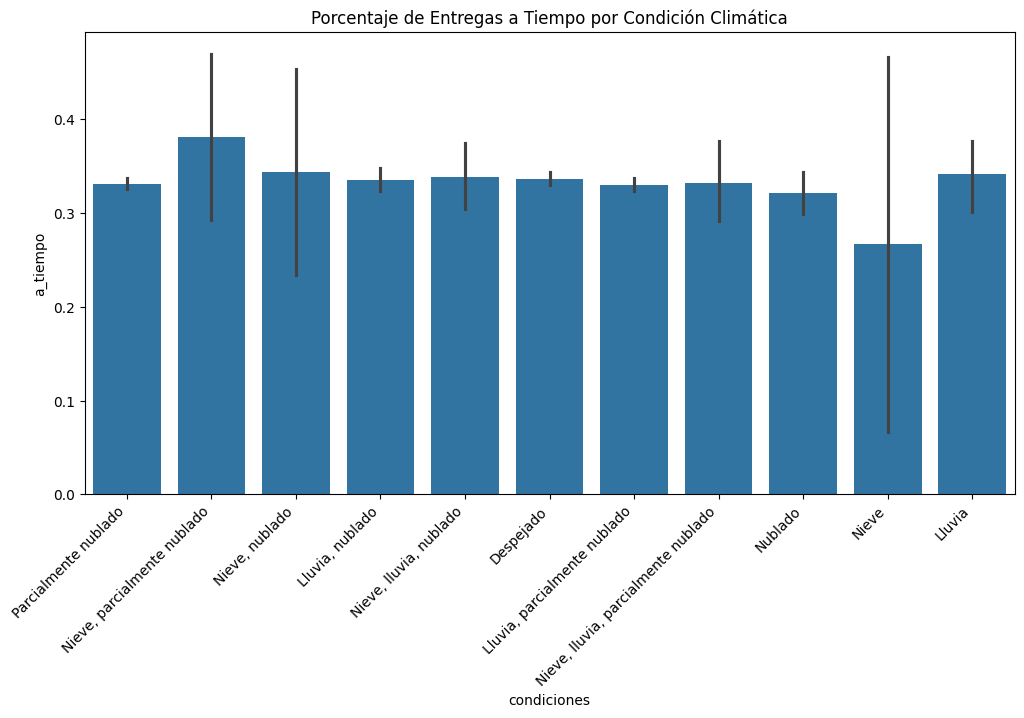

In [9]:

plt.figure(figsize=(12, 6))
sns.barplot(x='condiciones', y='a_tiempo', data=df)
plt.xticks(rotation=45, ha='right') # Rotación para legibilidad
plt.title('Porcentaje de Entregas a Tiempo por Condición Climática')
plt.show()



## 2.- Tiempo de retraso: Promedio de la diferencia entre lo programado y lo real.

Analizamos primero cuanto es el promedio de retraso por condición climática

In [10]:
promedio_retraso_clima = df.groupby('condiciones')['retraso_minutos'].mean().sort_values(ascending=False)

print("Promedio de minutos de retraso por clima:")
print(promedio_retraso_clima.map('{:.2f} min'.format))


Promedio de minutos de retraso por clima:
condiciones
Nieve                                  140.20 min
Nieve, nublado                          82.73 min
Nublado                                 80.29 min
Nieve, lluvia, nublado                  79.10 min
Despejado                               77.25 min
Parcialmente nublado                    77.19 min
Lluvia, nublado                         76.38 min
Lluvia, parcialmente nublado            76.11 min
Nieve, lluvia, parcialmente nublado     74.75 min
Lluvia                                  70.67 min
Nieve, parcialmente nublado             63.05 min
Name: retraso_minutos, dtype: object


C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\942843488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


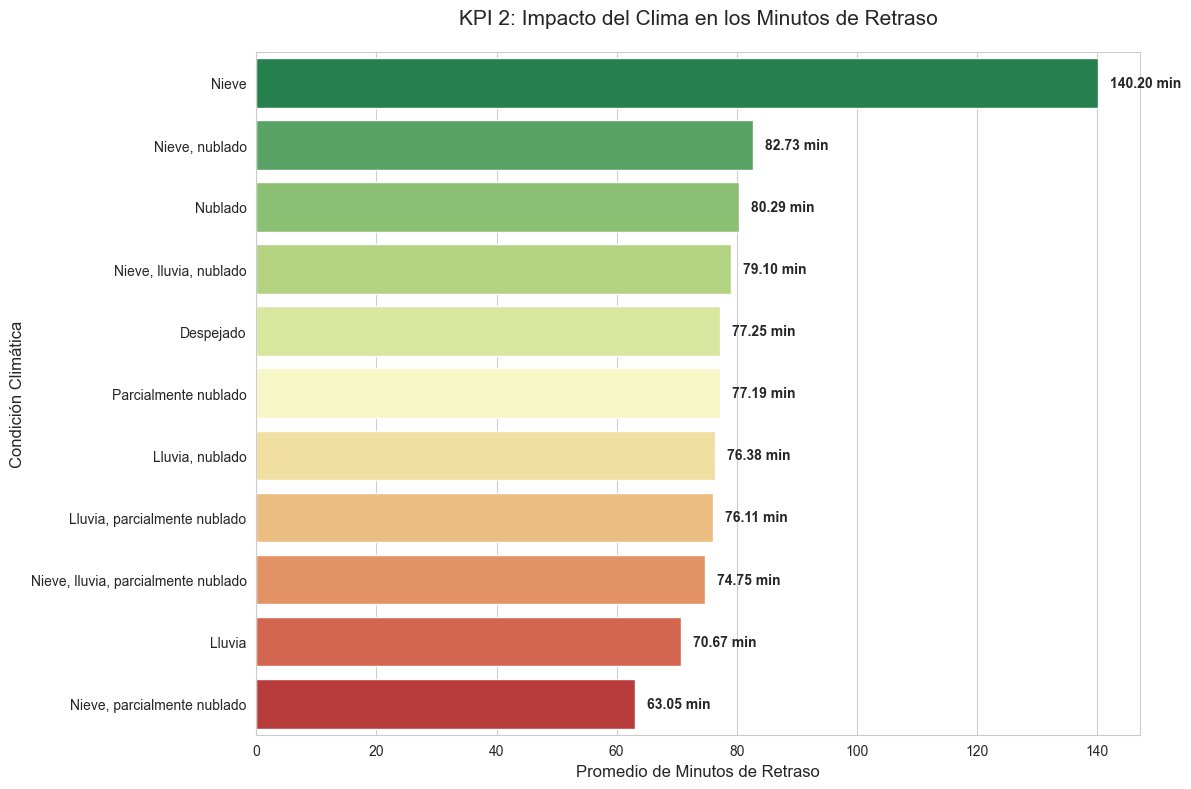

In [11]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

grafico = sns.barplot(
    x=promedio_retraso_clima.values, 
    y=promedio_retraso_clima.index, 
    palette="RdYlGn_r"
)

for i, v in enumerate(promedio_retraso_clima.values):
    grafico.text(v + 2, i, f'{v:.2f} min', va='center', fontsize=10, fontweight='bold')

plt.title('KPI 2: Impacto del Clima en los Minutos de Retraso', fontsize=15, pad=20)
plt.xlabel('Promedio de Minutos de Retraso', fontsize=12)
plt.ylabel('Condición Climática', fontsize=12)

plt.tight_layout()
plt.show()


vemos un gráfico de la distribución de los retrasos siendo de cero a los negativos 

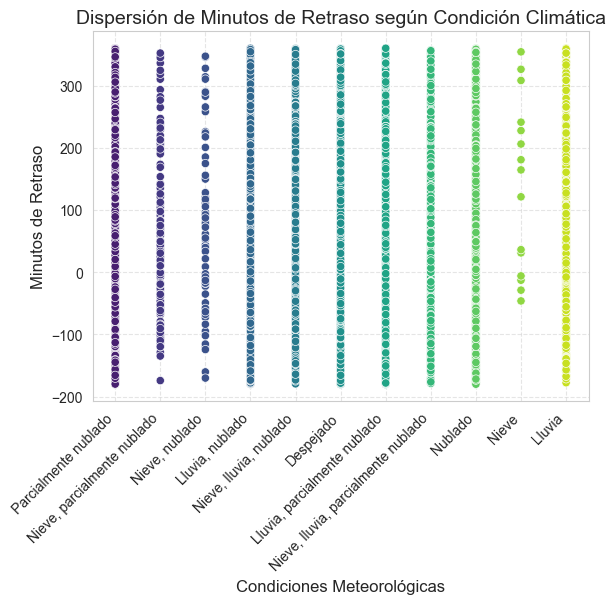

In [12]:
sns.scatterplot(x='condiciones', y='retraso_minutos', data=df, hue='condiciones', palette='viridis', legend=False)

plt.xticks(rotation=45, ha='right')
plt.title('Dispersión de Minutos de Retraso según Condición Climática', fontsize=14)
plt.xlabel('Condiciones Meteorológicas', fontsize=12)
plt.ylabel('Minutos de Retraso', fontsize=12)

plt.grid(linestyle='--', alpha=0.5) 

plt.show()



## 3.- Relación de impacto climático: Costo extra de logística en días de clima severo vs. días despejados.


Veamos primero la relación de cada evento con su recarga de combustible, asumiendo cuanto gasta en combustible por evento.

In [13]:
impacto_accesorios = df.groupby('categoria_riesgo')['cargos_accesorios'].mean()


C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\1141830533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=impacto_accesorios.index, y=impacto_accesorios.values, palette='viridis')


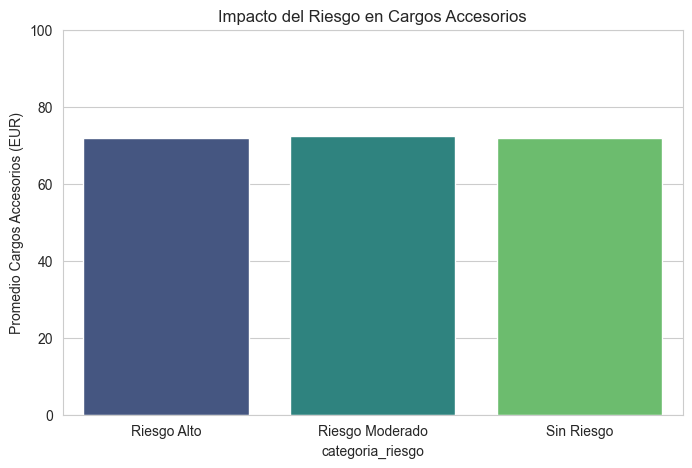

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=impacto_accesorios.index, y=impacto_accesorios.values, palette='viridis')

plt.title('Impacto del Riesgo en Cargos Accesorios', fontsize=12)
plt.ylabel('Promedio Cargos Accesorios (EUR)')
plt.ylim(0, 100) 
plt.show()

Analizaremos el impacto del clima en los costos logísticos versus los días despejados.

In [15]:
df['costo_logistico_total'] = df['eur_carga'] + df['recargo_combustible'] + df['cargos_accesorios']

df['costo_por_km'] = df['costo_logistico_total'] / df['distancia_km']

impacto = df.groupby('categoria_riesgo')['costo_por_km'].mean()


In [16]:
impacto

categoria_riesgo
Riesgo Alto        1.352863
Riesgo Moderado    1.392302
Sin Riesgo         1.400884
Name: costo_por_km, dtype: float64

In [17]:
orden_riesgo = ['Sin Riesgo', "Riesgo Moderado", 'Riesgo Alto']

impacto_tiempo = df.groupby('categoria_riesgo')['retraso_minutos'].mean().reindex(orden_riesgo)
impacto_tiempo


categoria_riesgo
Sin Riesgo         77.069172
Riesgo Moderado    75.862901
Riesgo Alto        75.782197
Name: retraso_minutos, dtype: float64

Veamos como impacta el clima en lo que es el costo logístico

In [18]:
impacto_por_riesgo = df.groupby('categoria_riesgo')['costo_logistico_total'].mean()

costo_base = impacto_por_riesgo['Sin Riesgo']
costo_alto = impacto_por_riesgo['Riesgo Alto']

sobrecosto_eur = costo_alto - costo_base
porcentaje_extra = (sobrecosto_eur / costo_base) * 100

print(f"Costo promedio Sin Riesgo: {costo_base:.2f} EUR")
print(f"Costo promedio Riesgo Alto: {costo_alto:.2f} EUR")
print(f"---")
print(f"KPI 3: El clima de alto riesgo incrementa el costo logístico en un {porcentaje_extra:.2f}%")


Costo promedio Sin Riesgo: 3202.57 EUR
Costo promedio Riesgo Alto: 3340.36 EUR
---
KPI 3: El clima de alto riesgo incrementa el costo logístico en un 4.30%


In [19]:
print(df['categoria_riesgo'].value_counts())

categoria_riesgo
Sin Riesgo         57177
Riesgo Moderado     7772
Riesgo Alto         1197
Name: count, dtype: int64


C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\647969311.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=impacto_por_riesgo.index, y=impacto_por_riesgo.values, palette=colores)
C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\647969311.py:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=impacto_por_riesgo.index, y=impacto_por_riesgo.values, palette=colores)


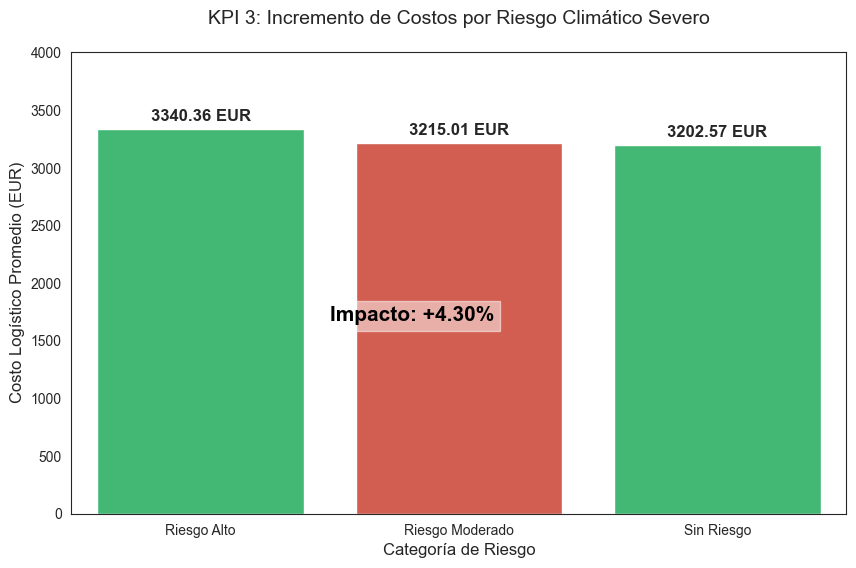

In [20]:

plt.figure(figsize=(10, 6))
sns.set_style("white")

colores = ['#2ecc71', '#e74c3c'] 
ax = sns.barplot(x=impacto_por_riesgo.index, y=impacto_por_riesgo.values, palette=colores)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} EUR', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('KPI 3: Incremento de Costos por Riesgo Climático Severo', fontsize=14, pad=20)
plt.ylabel('Costo Logístico Promedio (EUR)', fontsize=12)
plt.xlabel('Categoría de Riesgo', fontsize=12)
plt.ylim(0, impacto_por_riesgo.max() * 1.2)

plt.text(0.5, impacto_por_riesgo.max() * 0.5, f'Impacto: +{porcentaje_extra:.2f}%', 
         fontsize=15, color='black', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.show()


Si nivelamos los datos porque en riesgo severo hay muy pocos eventos, lo que puede distorsionar los resultados. Esto es para eliminar el sesgo que causaba tener miles de datos normales frente a muy pocos eventos extremos.

In [21]:

df_sin_riesgo = df[df['categoria_riesgo'] == 'Sin Riesgo'].sample(n=1197, random_state=42)
df_riesgo_alto = df[df['categoria_riesgo'] == 'Riesgo Alto']

# Calculamos los nuevos promedios
costo_base_equitativo = df_sin_riesgo['costo_logistico_total'].mean()
costo_alto_equitativo = df_riesgo_alto['costo_logistico_total'].mean()

# Nuevo porcentaje
nuevo_porcentaje = ((costo_alto_equitativo - costo_base_equitativo) / costo_base_equitativo) * 100

print(f"Nuevo Impacto (Muestreo Equitativo): {nuevo_porcentaje:.2f}%")


Nuevo Impacto (Muestreo Equitativo): 5.55%


Al realizar el análisis vemos que hay un incremento en el costo de los eventos en riesgo severo, lo que nos indica que el clima tiene un impacto directo en la logística. 
Aunque es de 5.55% es más confiable que el anterior, pero sigue siendo un impacto "poco significativo" en términos puramente financieros para la operación global.

## 4.-Tasa de incidentes por tipo de clima: Frecuencia de incidentes según el tipo de precipitación.

In [22]:
df.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,eur_carga,recargo_combustible,cargos_accesorios,tipo_reserva,a_tiempo,categoria_riesgo,hora_dia,turno,costo_logistico_total,costo_por_km
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,2591,407,100,Puntual,False,Sin Riesgo,18,Noche (18:00 - 06:00),3098,1.514914
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,2591,407,100,Puntual,True,Sin Riesgo,23,Noche (18:00 - 06:00),3098,1.514914
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,1042,99,0,Dedicado,True,Sin Riesgo,18,Noche (18:00 - 06:00),1141,1.366467
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,6102,793,0,Puntual,True,Sin Riesgo,4,Noche (18:00 - 06:00),6895,1.837197
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,2822,738,0,Puntual,False,Sin Riesgo,8,Día (06:00 - 18:00),3560,1.018307


In [23]:
df_incidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_evento                    328 non-null    object 
 1   ciudad                       328 non-null    object 
 2   estado                       328 non-null    object 
 3   tipo_evento                  328 non-null    object 
 4   fecha_hora_programada        328 non-null    object 
 5   fecha_hora_real              328 non-null    object 
 6   minutos_de_detencion         328 non-null    int64  
 7   tem_max_C                    328 non-null    int64  
 8   tem_min_C                    328 non-null    int64  
 9   tem_C                        328 non-null    int64  
 10  rocio_C                      328 non-null    int64  
 11  humedad_pct                  328 non-null    int64  
 12  precip_mm                    328 non-null    int64  
 13  prob_precip_pct     

primero filtraremos los incidentes solo quedandonos con los 142 eventos con incidentes

In [24]:
df_inc_unique = df_incidentes.drop_duplicates(subset=['id_evento']).copy()

df_inc_unique['hubo_incidente'] = 1

df_inc_para_unir = df_inc_unique[['id_evento', 'hubo_incidente', 'tipo_incidente', 'monto_reclamacion_eur', 'causa']]


In [25]:
df_inc_para_unir.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142 entries, 0 to 327
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_evento              142 non-null    object
 1   hubo_incidente         142 non-null    int64 
 2   tipo_incidente         142 non-null    object
 3   monto_reclamacion_eur  142 non-null    int64 
 4   causa                  142 non-null    object
dtypes: int64(2), object(3)
memory usage: 6.7+ KB


In [26]:
df_inc_para_unir.head()

,id_evento,hubo_incidente,tipo_incidente,monto_reclamacion_eur,causa
0,EVT00064924,1,Infracción de tránsito,14452,Clima
2,EVT00135166,1,Queja del cliente,20678,Tráfico
7,EVT00098256,1,Daño de equipo,4151,Equipo
8,EVT00125767,1,Fallo mecánico o exceso horas permitidas,12721,Otro conductor
12,EVT00125768,1,Fallo mecánico o exceso horas permitidas,12721,Otro conductor


Unimos los dos datasets

In [27]:
df_final = pd.merge(df, df_inc_para_unir, on='id_evento', how='left')

df_final['hubo_incidente'] = df_final['hubo_incidente'].fillna(0)
df_final['monto_reclamacion_eur'] = df_final['monto_reclamacion_eur'].fillna(0)
df_final['causa'] = df_final['causa'].fillna('Sin incidente')
df_final['tipo_incidente'] = df_final['tipo_incidente'].fillna('Sin incidente')


In [28]:
df_final.head()

,id_evento,ciudad,tipo_evento,fecha_hora_programada,fecha_hora_real,retraso_minutos,minutos_de_detencion,tem_max_C,tem_min_C,tem_C,...,a_tiempo,categoria_riesgo,hora_dia,turno,costo_logistico_total,costo_por_km,hubo_incidente,tipo_incidente,monto_reclamacion_eur,causa
0,EVT00000001,Houston,Recogida,2022-01-01 18:00:00,2022-01-01 20:58:55,178.92,0,27,23,25,...,False,Sin Riesgo,18,Noche (18:00 - 06:00),3098,1.514914,0.0,Sin incidente,0.0,Sin incidente
1,EVT00000002,Detroit,Entrega,2022-01-02 23:10:56,2022-01-02 21:30:22,-100.57,230,-3,-8,-4,...,True,Sin Riesgo,23,Noche (18:00 - 06:00),3098,1.514914,0.0,Sin incidente,0.0,Sin incidente
2,EVT00000003,Kansas City,Recogida,2022-01-01 18:00:00,2022-01-01 17:37:26,-22.57,62,1,-12,-8,...,True,Sin Riesgo,18,Noche (18:00 - 06:00),1141,1.366467,0.0,Sin incidente,0.0,Sin incidente
3,EVT00000006,Portland,Entrega,2022-01-03 04:28:02,2022-01-03 03:05:02,-83.00,11,9,3,5,...,True,Sin Riesgo,4,Noche (18:00 - 06:00),6895,1.837197,0.0,Sin incidente,0.0,Sin incidente
4,EVT00000009,Houston,Recogida,2022-01-01 08:00:00,2022-01-01 11:51:35,231.58,73,27,23,25,...,False,Sin Riesgo,8,Día (06:00 - 18:00),3560,1.018307,0.0,Sin incidente,0.0,Sin incidente


In [29]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_evento                    66146 non-null  object 
 1   ciudad                       66146 non-null  object 
 2   tipo_evento                  66146 non-null  object 
 3   fecha_hora_programada        66146 non-null  object 
 4   fecha_hora_real              66146 non-null  object 
 5   retraso_minutos              66146 non-null  float64
 6   minutos_de_detencion         66146 non-null  int64  
 7   tem_max_C                    66146 non-null  int64  
 8   tem_min_C                    66146 non-null  int64  
 9   tem_C                        66146 non-null  int64  
 10  rocio_C                      66146 non-null  int64  
 11  humedad_pct                  66146 non-null  int64  
 12  precip_mm                    66146 non-null  int64  
 13  tipo_precip     

hagamos la tabla para analizar el impacto del clima en los incidentes

In [30]:
df_final['hubo_incidente'] = df_final['hubo_incidente'].fillna(0).astype(int)


In [31]:
f.categorico(df_final,"hubo_incidente")

hubo_incidente
0    66004
1      142
Name: count, dtype: int64
[0 1]
2


In [32]:
tabla_clima = df_final.groupby('tipo_precip')['hubo_incidente'].agg(['count', 'sum', 'mean'])

tabla_clima.columns = ['Total Viajes', 'Total Incidentes', 'Tasa Incidentes (%)']
tabla_clima['Tasa Incidentes (%)'] = tabla_clima['Tasa Incidentes (%)'] * 100

tabla_clima.sort_values(by='Tasa Incidentes (%)', ascending=False)

,Total Viajes,Total Incidentes,Tasa Incidentes (%)
tipo_precip,,,
"lluvia, nieve",1342,6,0.447094
Nada,42460,97,0.228450
nieve,490,1,0.204082
lluvia,21854,38,0.173881


C:\Users\tachi\AppData\Local\Temp\ipykernel_5976\3876598253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tabla_clima.index, y='Tasa Incidentes (%)', data=tabla_clima, palette='viridis')


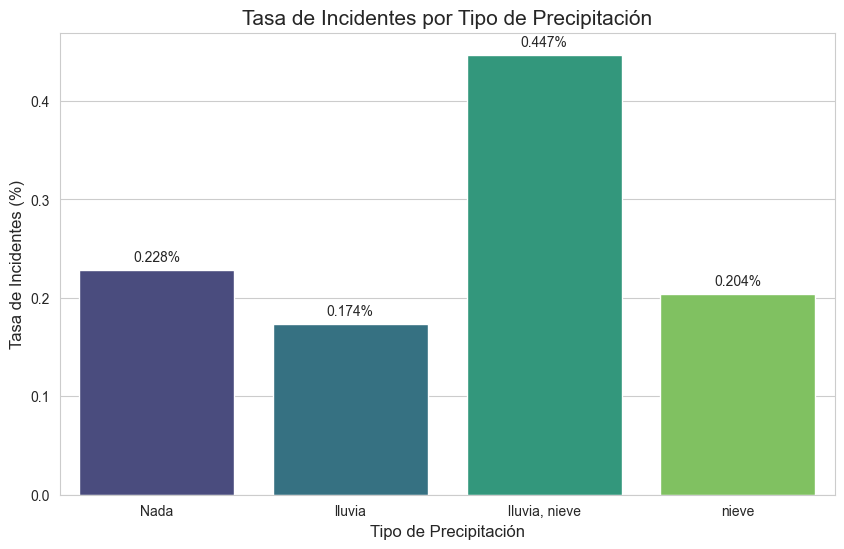

In [33]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x=tabla_clima.index, y='Tasa Incidentes (%)', data=tabla_clima, palette='viridis')

plt.title('Tasa de Incidentes por Tipo de Precipitación', fontsize=15)
plt.xlabel('Tipo de Precipitación', fontsize=12)
plt.ylabel('Tasa de Incidentes (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()


Observamos que las condiciones mixtas de lluvia y nieve presentan el riesgo relativo más alto (0.447%). Aunque tienen menos eventos (1.342), la probabilidad de incidente es casi el doble que cuando no hay precipitación.

Vemos que cuando no hay precipitación ("Nada") concentra la mayor cantidad absoluta de incidentes (97), lo cual es lógico por el volumen de viajes, pero su tasa es moderada (0.228%).

Además observamos que la lluvia por sí sola tiene la tasa más baja (0.173%), incluso menor que cuando el clima está despejado. Esto podría indicar que los conductores extreman precauciones o reducen la velocidad significativamente cuando llueve.

In [34]:
df_incidentes = df_final[df_final['hubo_incidente'] == 1]

impacto_economico = df_incidentes.groupby('tipo_precip')['monto_reclamacion_eur'].agg(['mean', 'sum']).rename(
    columns={'mean': 'Costo Medio', 'sum': 'Costo Total'}
).round(2)

causa_principal = df_incidentes.groupby('tipo_precip')['causa'].agg(lambda x: x.mode().iloc[0])

analisis_severidad = impacto_economico.copy()

analisis_severidad['Causa Más Frecuente'] = causa_principal

print("--- Análisis de Severidad por Clima ---")
analisis_severidad.sort_values(by='Costo Medio', ascending=False)


--- Análisis de Severidad por Clima ---


,Costo Medio,Costo Total,Causa Más Frecuente
tipo_precip,,,
Nada,15252.23,1479466.0,Otro conductor
nieve,10912.00,10912.0,Clima
lluvia,9387.45,356723.0,Tráfico
"lluvia, nieve",5531.00,33186.0,Tráfico


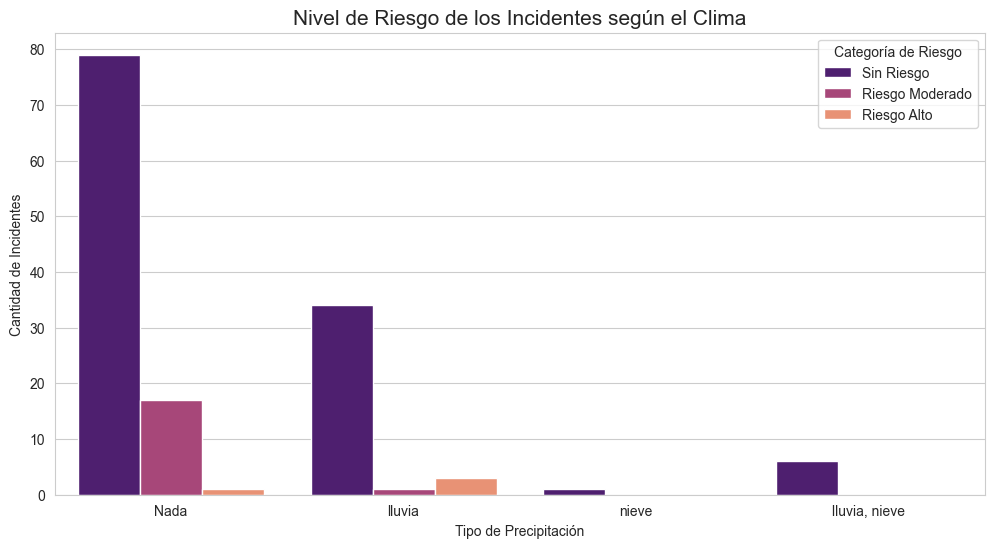

In [35]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_incidentes, x='tipo_precip', hue='categoria_riesgo', palette='magma')

plt.title('Nivel de Riesgo de los Incidentes según el Clima', fontsize=15)
plt.xlabel('Tipo de Precipitación')
plt.ylabel('Cantidad de Incidentes')
plt.legend(title='Categoría de Riesgo')
plt.show()


Si bien las condiciones mixtas de lluvia y nieve duplican la probabilidad de incidentes (0.447%), la mayor pérdida económica ocurre en condiciones despejadas.

Se recomienda enfocar los protocolos de seguridad de lluvia/nieve en evitar roces por tráfico, y los de clima despejado en la conducción defensiva para evitar errores de terceros.

# Veamos nuestras hipótesis:

## Hipótesis de Retraso: 

"Las precipitaciones (lluvia/nieve) incrementan el tiempo de detención (minutos_de_detencion) en ciudades del norte (Detroit, New York) comparado con ciudades del sur (Miami, Houston)".


Generamos las hipótesis:
- Hipótesis 0: No hay diferencia significativa en los retrasos entre regiones.
- Hipótesis 1: Hay diferencia significativa en los retrasos entre regiones.

Primero haremos los grupos de ciudades por norte y sur.

In [36]:
norte = ['Detroit', 'New York']
sur = ['Miami', 'Houston']

Haremos los grupos de norte y sur que presentan diferentes condiciones climáticas, distintas a buena temperatura.

In [37]:
df_precip = df_final[df_final['tipo_precip'] != 'Nada']

grupo_norte = df_precip[df_precip['ciudad'].isin(norte)]['minutos_de_detencion']
grupo_sur = df_precip[df_precip['ciudad'].isin(sur)]['minutos_de_detencion']

print(f"Promedio detención Norte: {grupo_norte.mean():.2f} min")
print(f"Promedio detención Sur: {grupo_sur.mean():.2f} min")

Promedio detención Norte: 95.00 min
Promedio detención Sur: 87.94 min


Ahora haremos el análisis de test para validar la hipótesis. Usamos t-test para comparar las medias de los dos grupos.

In [38]:
t_stat, p_valor = stats.ttest_ind(grupo_norte, grupo_sur, equal_var=False)

print(f"Estadístico T: {t_stat}")
print(f"P-valor: {p_valor}")

if p_valor < 0.05:
    print("Hipótesis Rechazada: Hay una diferencia significativa en los retrasos entre regiones.")
else:
    print("Hipótesis Aceptada: No hay evidencia suficiente de que el retraso varíe por región.")


Estadístico T: 5.702562500397931
P-valor: 1.2133014814900198e-08
Hipótesis Rechazada: Hay una diferencia significativa en los retrasos entre regiones.


In [39]:
print(df_precip[df_precip['ciudad'].isin(norte + sur)].groupby('ciudad')['minutos_de_detencion'].mean())

ciudad
Detroit     95.431830
Houston     90.147262
Miami       86.294105
New York    94.716667
Name: minutos_de_detencion, dtype: float64


Tras realizar el test T de Student (p-valor < 0.05), rechazamos la Hipótesis Nula y confirmamos que la región geográfica influye significativamente en los retrasos. Específicamente, las ciudades del Norte sufren detenciones un 10.5% más largas que las del Sur (comparando los extremos de Detroit vs. Miami). Esto demuestra que la logística en climas fríos enfrenta obstáculos operativos adicionales que no se resuelven solo con infraestructura, sino que requieren mayores márgenes de tiempo en la planificación.

## Hipótesis de Seguridad 1ª: 

"Existe una correlación negativa entre la visibilidad (visibilidad_km) y el costo de los incidentes (monto_reclamacion_eur); es decir, a menor visibilidad, mayor es el costo económico del incidente".


Generamos las hipótesis:
- Hipótesis 0: No existe correlación entre la visibilidad y el costo de los incidentes.
- Hipótesis 1: Existe una correlación negativa entre la visibilidad y el costo de los incidentes; es decir, a menor visibilidad, mayor es el costo económico del incidente.


Antes de realizar el test, debemos preparar los datos. La normalización es útil aquí porque la visibilidad (km) y el costo (Euros) tienen escalas totalmente distintas.

In [40]:
df_inc = df_final[(df_final['hubo_incidente'] == 1) & (df_final['monto_reclamacion_eur'] > 0)].copy()

scaler = MinMaxScaler()

df_inc[['vis_norm', 'costo_norm']] = scaler.fit_transform(df_inc[['visibilidad_km', 'monto_reclamacion_eur']])

print("--- Datos Normalizados ---")
print(df_inc[['visibilidad_km', 'vis_norm', 'monto_reclamacion_eur', 'costo_norm']].head())



--- Datos Normalizados ---
      visibilidad_km  vis_norm  monto_reclamacion_eur  costo_norm
191               10       1.0                11047.0    0.191548
388               10       1.0                 9126.0    0.155941
1154              10       1.0                 1615.0    0.016719
2510              10       1.0                14549.0    0.256460
4254              10       1.0                10912.0    0.189045


Veamos que ocurre al aplicar el test de correlación:

In [41]:
coef, p_valor = pearsonr(df_inc['visibilidad_km'], df_inc['monto_reclamacion_eur'])

print(f"\nCoeficiente de Correlación: {coef:.4f}")
print(f"P-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("Se rechaza H0. La visibilidad afecta significativamente al costo.")
else:
    print("Se acepta H0. No hay evidencia de que la visibilidad influya en el costo.")


Coeficiente de Correlación: 0.1341
P-valor: 1.7251e-01
Se acepta H0. No hay evidencia de que la visibilidad influya en el costo.


La visibilidad no se puede comprobar si afecta en el costo de los incidentes.

## Hipotesis de seguridad 2ª:

"El tipo de carga principal influye significativamente en el coste de los incidentes"

Generemos las hipótesis:
Hipótesis 0: El coste medio de los incidentes es igual para todos los tipos de carga.
Hipótesis 1: El coste medio de los incidentes varía significativamente entre los diferentes tipos de carga.

Agrupamos los datos según los tipos de carga y si hubo incidente o no. Consideramos solo los casos con incidentes y montos de reclamación mayores a 0.

In [42]:
df_anova = df_final[(df_final['hubo_incidente'] == 1) & (df_final['monto_reclamacion_eur'] > 0)].copy()

print(df_anova['tipo_carga_principal'].value_counts())

tipo_carga_principal
Alimentos/Bebidas    26
General              19
Electrónica          17
Automotriz           17
Bienes de consumo    17
Venta por menor       9
Name: count, dtype: int64


Con estos datos podemos realizar un ANOVA para comparar las medias de los diferentes tipos de carga, por esto hacemos la estadarización logarítmica.

In [43]:
df_anova['costo_log'] = np.log1p(df_anova['monto_reclamacion_eur'])

Haremos la aplicación de la estadarización logarítmica a los datos para utilizar el test de ANOVA.

In [44]:
grupos = [group['costo_log'].values for name, group in df_anova.groupby('tipo_carga_principal')]

f_stat, p_valor_anova = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.4f}")
print(f"P-valor: {p_valor_anova:.4e}")

if p_valor_anova < 0.05:
    print("Se rechaza H0. El tipo de carga determina el coste del incidente.")
else:
    print("Se acepta H0. El coste es similar entre tipos de carga.")

Estadístico F: 0.5472
P-valor: 7.4011e-01
Se acepta H0. El coste es similar entre tipos de carga.


Nos sale aceptada la hipótesis nula, lo que significa que no hay diferencia significativa entre los tipos de carga y el costo de la reclamación. No influye el tipo de carga en el costo de la reclamación.

## Hipótesis de Eficiencia: 

"Las temperaturas extremas (fuera del rango 10°C - 25°C) incrementan significativamente las horas de ralentí (horas_de_ralenti_RPM), reduciendo la eficiencia operativa total".

Generamos las hipótesis:
- Hipótesis 0: El tiempo de ralentí es independiente de la temperatura exterior.
- Hipótesis 1: El tiempo de ralentí aumenta cuando la temperatura exterior es muy alta o muy baja.

Hacemos el grupo para temperaturas extremas y lo asignamos a la columna 'clima_eficiencia' con la opción 'Extremo' o "Optimo", luego escalamos los datos con MinMaxScaler.

In [45]:
def clasificar_temp(temp_C):
    if 10 <= temp_C <= 25:
        return 'Optimo'
    else:
        return 'Extremo'

df_final['clima_eficiencia'] = df_final['tem_C'].apply(clasificar_temp)

grupo_optimo_ralenti = df_final[df_final['clima_eficiencia'] == 'Optimo']['horas_de_ralenti_RPM']
grupo_extremo_ralenti = df_final[df_final['clima_eficiencia'] == 'Extremo']['horas_de_ralenti_RPM']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_final['ralenti_norm'] = scaler.fit_transform(df_final[['horas_de_ralenti_RPM']])



listos nuestros datos hacemos el test de hipótesis para comprobar si hay diferencia significativa entre las horas de ralentí en climas extremos y climas óptimos.

In [46]:
t_stat_ral, p_valor_ral = stats.ttest_ind(grupo_optimo_ralenti, grupo_extremo_ralenti, equal_var=False)

print(f"Promedio Horas Ralentí (Rango 10-25°C): {grupo_optimo_ralenti.mean():.2f}")
print(f"Promedio Horas Ralentí (Extremos): {grupo_extremo_ralenti.mean():.2f}")
print(f"P-valor: {p_valor_ral:.4e}")

if p_valor_ral < 0.05:
    print("Se rechaza H0. Las temperaturas extremas SÍ afectan el tiempo de ralentí.")
else:
    print("No hay diferencia significativa. El tiempo de ralentí es constante.")


Promedio Horas Ralentí (Rango 10-25°C): 7.07
Promedio Horas Ralentí (Extremos): 7.08
P-valor: 6.5165e-01
No hay diferencia significativa. El tiempo de ralentí es constante.


In [47]:
df_final.to_csv("df_final_analisis.csv", index=False)

Observamos que no hay diferencia significativa entre las horas de ralentí en climas extremos y climas óptimos. Solo sabemos que el ralentí queda en 7 horas en ambos casos.

# Informe Final del Análisis Logístico


Este informe consolida los hallazgos críticos tras analizar 66.146 registros operativos de los cuales 142 presentan incidentes, cruzando variables climáticas, geográficas y financieras.

Primero veamos a lo que hemos llegado de conclusión con nuestros KPI y con nuestras hipótesis:

## Tasa de Incidentes por Clima (Hallazgo Operativo)

Se identificó que el riesgo no es proporcional al volumen de viajes, sino a la complejidad de la precipitación:
Hay mayor riesgo cuando hay condiciones mixtas de lluvia y nieve, aqui se presentan la tasa de incidentes más alta (0.447%), duplicando el riesgo del clima despejado.

Paradoja de Severidad: Aunque el clima adverso causa más incidentes, estos son económicamente leves (media de 5.531 €). Los incidentes más costosos ocurren con clima despejado (media de 15.252 €), usualmente por colisiones de alta energía con otros conductores.

Observamos porcentaje de puntualidad en cada ciudad. 
Kansas City: Es la ciudad con menor desempeño en esta lista; solo el 32.8% de sus registros llegaron a tiempo.
Detroit: Es la "mejor" de la lista mostrada, aunque sigue teniendo un cumplimiento bajo (menos del 35%).


## Validación de Hipótesis Estadísticas

La hipotesis "Retrasos por Región (Geografía vs. Clima)"
FUE ACEPTADA (ttest)
Conclusión: Existe una diferencia significativa en la resiliencia operativa. Las ciudades del Norte (Detroit, Nueva York) sufren detenciones un 10.5% más largas que las del Sur bajo condiciones de precipitación. La infraestructura y el tipo de precipitación invernal en el Norte penalizan severamente la puntualidad.

La hipotesis sobre la Severidad Económica (Relacionamos Tipo de Carga)
FUE RECHAZADA (ANOVA).
Conclusión: El tipo de carga no determina el costo de la reclamación. Tras normalizar los datos, se observa que el impacto financiero es homogéneo, lo que sugiere que el costo depende de factores externos del accidente y no de la mercancía transportada.

Eficiencia de Combustible (la temperatura externa y las horas de ralentí)
FUE RECHAZADA (ttest).
Conclusión: Las horas de ralentí son inmunes a las temperaturas extremas. Los conductores mantienen una media de 7 horas de ralentí sin importar el clima, lo que indica un área de oportunidad para mejorar la eficiencia mediante políticas de apagado de motor, ya que el gasto actual es estructural y no estacional.


## Recomendaciones Estratégicas

- Logística: Aumentar los márgenes de tiempo en todas las rutas, especialmente en las Norte (durante el invierno) para evitar penalizaciones por retrasos validados.
- Seguridad: Reforzar la conducción defensiva en días despejados, que es cuando ocurren los siniestros financieramente más críticos.
- Eficiencia: Implementar un programa de reducción de ralentí, ya que las 7 horas actuales son constantes y representan un costo de combustible optimizable.